In [1]:
import os
from typing import List
from pydantic import BaseModel
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, START, END

In [2]:
from dotenv import load_dotenv

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')

In [3]:
# Prepare vector store
docs = TextLoader('research_notes.txt', encoding='utf-8').load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

embedding = OpenAIEmbeddings()
vector_store = FAISS.from_documents(
    documents=chunks,
    embedding=embedding
)
retriever = vector_store.as_retriever()

In [4]:
# LLM
from langchain.chat_models import init_chat_model

llm = init_chat_model('openai:gpt-4o')

In [5]:
# State schema definition
class CoTState(BaseModel):
    question:str
    sub_steps:List[str] = []
    retrieved_docs:List[Document] = []
    answer:str = ""

In [6]:
# Node 1: Split into sub-questions
def split_step(state:CoTState)->CoTState:
    prompt = f"Break the question into 2-3 reasoning steps: \n\n{state.question}"
    result = llm.invoke(prompt).content
    sub_ques = [line.strip("- ") for line in result.split('\n') if line.strip()]

    return state.model_copy(update={'sub_steps':sub_ques})

In [7]:
# Node 2: Retrieve for each sub-steps
def retrieve_per_step(state:CoTState)->CoTState:
    all_docs = []
    for step in state.sub_steps:
        relevant_docs = retriever.invoke(step)
        all_docs.extend(relevant_docs)

    return state.model_copy(update={'retrieved_docs':all_docs})

In [8]:
# Node 3: Generate Final Answer
def generate_answer(state:CoTState)->CoTState:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])

    prompt = f"""
You are answering a complex question using reasoning and retrieved documents.

Question: {state.question}

Relevant Information:
{context}

Now synthesize a well-reasoned final answer."""
    
    result = llm.invoke(prompt).content.strip()
    return state.model_copy(update={'answer':result})

In [10]:
graph = StateGraph(CoTState)

graph.add_node('split_step', split_step)
graph.add_node('retrieve_per_step', retrieve_per_step)
graph.add_node('generate_answer', generate_answer)

graph.set_entry_point('split_step')
graph.add_edge('split_step', 'retrieve_per_step')
graph.add_edge('retrieve_per_step', 'generate_answer')
graph.add_edge('generate_answer', END)

CoTRAG = graph.compile()

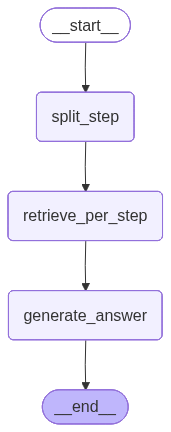

In [11]:
from IPython.display import Image, display

display(Image(CoTRAG.get_graph().draw_mermaid_png()))

In [12]:
query = 'what are the additional experiments in Transformers evaluation?'
state = CoTState(question=query)
results = CoTRAG.invoke(state)

print(f"Reasoning steps: \n{results['sub_steps']}")
print(f"Answer: \n{results['answer']}")

Reasoning steps: 
['To determine the additional experiments involved in Transformers evaluation, you can break the question into the following reasoning steps:', '1. **Understanding Standard Evaluation Practices**:', 'Begin by identifying the common evaluation metrics and practices used in assessing Transformer models. This includes tasks like language modeling, translation quality (e.g., BLEU scores for machine translation), and accuracy on benchmark datasets.', '2. **Identifying Gaps or Areas for Improvement**:', 'Consider the limitations of standard evaluations and where additional experiments might provide more insights. This could involve examining aspects such as robustness to adversarial attacks, generalization to unseen data, or performance under resource constraints (e.g., limited computational power or smaller datasets).', '3. **Proposing Additional Experiments**:', 'Suggest specific experiments to address these identified gaps. This could include testing on diverse datasets 

In [ ]:
query = 'what are the additional experiments in Transformers evaluation?'
state = CoTState(question=query)
results = CoTRAG.invoke(state)
for s in results['sub_steps']:
    print(s)

print(f"\nAnswer: \n{results['answer']}")

To determine the additional experiments involved in Transformers evaluation, you can break the question into the following reasoning steps:
1. **Understanding Standard Evaluation Practices**:
Begin by identifying the common evaluation metrics and practices used in assessing Transformer models. This includes tasks like language modeling, translation quality (e.g., BLEU scores for machine translation), and accuracy on benchmark datasets.
2. **Identifying Gaps or Areas for Improvement**:
Consider the limitations of standard evaluations and where additional experiments might provide more insights. This could involve examining aspects such as robustness to adversarial attacks, generalization to unseen data, or performance under resource constraints (e.g., limited computational power or smaller datasets).
3. **Proposing Additional Experiments**:
Suggest specific experiments to address these identified gaps. This could include testing on diverse datasets to evaluate model generalization, cond